In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Library berhasil di-import!")

✅ Library berhasil di-import!


c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('fiverr-data-gigs-cleaned.csv')   # ← ubah kalau path-nya beda

print("Shape dataset:", df.shape)
print("Kolom:", df.columns.tolist())

# Cleaning
def clean_reviewers(x):
    if isinstance(x, str):
        x = x.replace('1k+', '1000').replace('k+', '1000').replace(',', '')
        try:
            return int(float(x))
        except:
            return np.nan
    return x

df_clean = df.copy()
df_clean['Number of Reviewers'] = df_clean['Number of Reviewers'].apply(clean_reviewers)
df_clean['Average Rating'] = pd.to_numeric(df_clean['Average Rating'], errors='coerce')
df_clean['Price (USD)'] = pd.to_numeric(df_clean['Price (USD)'], errors='coerce')

df_clean = df_clean.dropna(subset=['Number of Reviewers'])

print("\n✅ Dataset sudah dibersihkan!")
print(df_clean[['Number of Reviewers', 'Average Rating', 'Price (USD)']].describe())

Shape dataset: (1259, 5)
Kolom: ['Title', 'Seller Level', 'Average Rating', 'Number of Reviewers', 'Price (USD)']

✅ Dataset sudah dibersihkan!
       Number of Reviewers  Average Rating   Price (USD)
count          1259.000000      629.000000   1259.000000
mean             38.870532        4.955167     71.395647
std             132.687022        0.186638    337.072615
min               0.000000        1.000000      5.180952
25%               0.000000        5.000000     10.361905
50%               0.000000        5.000000     20.719048
75%              16.000000        5.000000     51.790476
max            1000.000000        5.000000  10357.642857


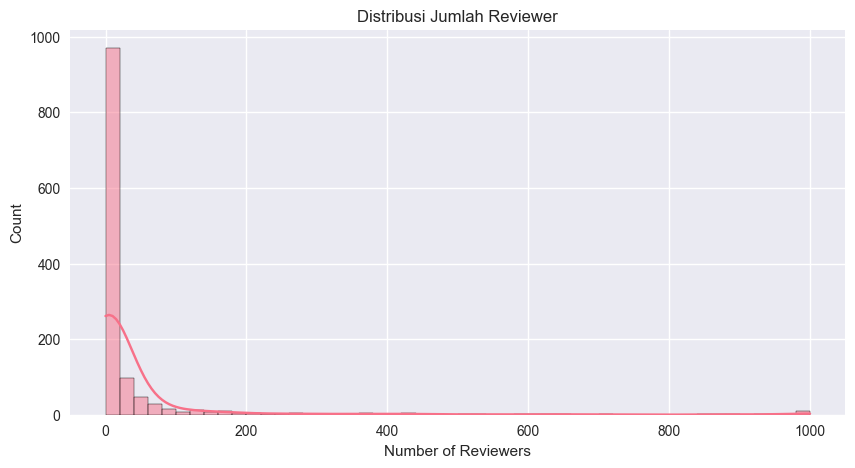

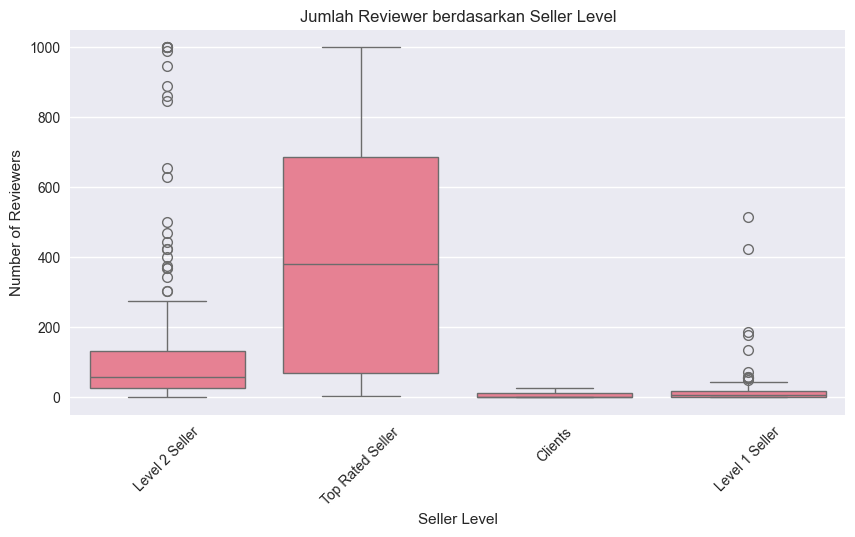

In [4]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['Number of Reviewers'], bins=50, kde=True)
plt.title('Distribusi Jumlah Reviewer')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Seller Level', y='Number of Reviewers', data=df_clean)
plt.xticks(rotation=45)
plt.title('Jumlah Reviewer berdasarkan Seller Level')
plt.show()

In [5]:
df_clean['title_length'] = df_clean['Title'].str.len()
df_clean['has_scraping'] = df_clean['Title'].str.contains('scraping|scrape|scrapper', case=False).astype(int)
df_clean['has_excel']   = df_clean['Title'].str.contains('excel|vba|macro|google sheet', case=False).astype(int)
df_clean['has_python']  = df_clean['Title'].str.contains('python', case=False).astype(int)
df_clean['has_etl']     = df_clean['Title'].str.contains('etl|pipeline|spark|airflow', case=False).astype(int)

# Dummy variable Seller Level
df_clean = pd.get_dummies(df_clean, columns=['Seller Level'], drop_first=True)

print("✅ Fitur baru sudah dibuat!")

✅ Fitur baru sudah dibuat!


MAE : 41.06560134887695
R²  : 0.21703553199768066


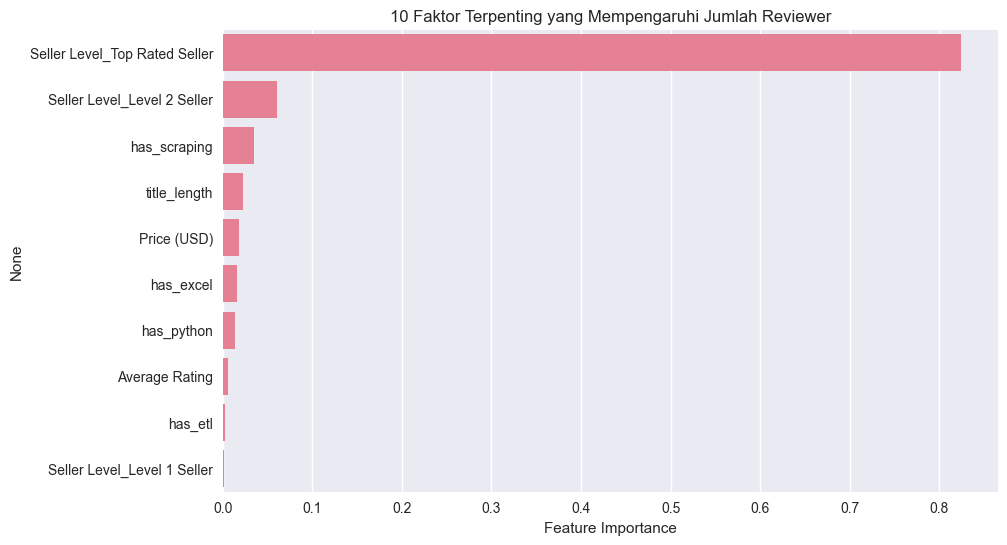

In [6]:
# Modeling
features = ['Average Rating', 'Price (USD)', 'title_length', 
            'has_scraping', 'has_excel', 'has_python', 'has_etl'] + \
           [col for col in df_clean.columns if col.startswith('Seller Level_')]

X = df_clean[features]
y = df_clean['Number of Reviewers']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

# Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values[:10], y=importances.index[:10])
plt.title('10 Faktor Terpenting yang Mempengaruhi Jumlah Reviewer')
plt.xlabel('Feature Importance')
plt.show()